## Use TF-IDF and BOW on my all of my essays to get a better understanding of how I write ad how LLMs work

### Imports

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', 120)

## Continue making the dataset you began in class-- the dataset should have 1 column and at least 1000 rows, each row should be a sentence from your own writing. 

In [ ]:
with open('AEFP.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

raw_text = raw_text.lstrip('\ufeff')

sentences = re.split(r'(?<=[.!?])\s+', raw_text)

sentences = [s.strip() for s in sentences if s.strip() and len(s.strip()) > 5]

df = pd.DataFrame({'text': sentences})
print(f'Total sentences: {len(df)}')
df.head()

Total sentences: 1276


,text
0,Is the American Dream all that it sets out to be?
1,Or is it just an illusion that drives the most hopeful insane?
2,"All characters in The Great Gatsby are drawn to New York for promises of money, connections, and love, regardless of..."
3,What every character has in common is that they all drive themselves insane whilst chasing this unattainable fantasy.
4,"The last two or three chapters of the novel make that claim very obvious with Gatsby’s death, and Nick’s leaving New..."


##  Create a new column called “clean_text.” Convert all text to lowercase. Remove punctuation, numbers, and extra spaces from the writing samples. Compare one original sentence and one cleaned sentence.

In [ ]:
def clean(text):
    text = text.lower()                          
    text = re.sub(r'\d+', '', text)
    text = re.sub(r"[^a-z\s]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean)
df.head(3)

,text,clean_text
0,Is the American Dream all that it sets out to be?,is the american dream all that it sets out to be
1,Or is it just an illusion that drives the most hopeful insane?,or is it just an illusion that drives the most hopeful insane
2,"All characters in The Great Gatsby are drawn to New York for promises of money, connections, and love, regardless of...",all characters in the great gatsby are drawn to new york for promises of money connections and love regardless of th...


In [21]:
print(df.loc[4, 'text'])
print(df.loc[4, 'clean_text'])

The last two or three chapters of the novel make that claim very obvious with Gatsby’s death, and Nick’s leaving New York.
the last two or three chapters of the novel make that claim very obvious with gatsby s death and nick s leaving new york


S is left as its own word when it comes after an apostophe that was removed from the string/list/whatever the things are

## Tokenize each sentence into individual words. What does tokenization do to a sentence?

In [5]:
df['tokens'] = df['clean_text'].apply(lambda s: s.split())
df[['clean_text', 'tokens']].head(3)

,clean_text,tokens
0,is the american dream all that it sets out to be,"[is, the, american, dream, all, that, it, sets, out, to, be]"
1,or is it just an illusion that drives the most hopeful insane,"[or, is, it, just, an, illusion, that, drives, the, most, hopeful, insane]"
2,all characters in the great gatsby are drawn to new york for promises of money connections and love regardless of th...,"[all, characters, in, the, great, gatsby, are, drawn, to, new, york, for, promises, of, money, connections, and, lov..."


tokenizing basically allows you to go in and grab specific words in a sentence or iterate over words in a sentence, it basically allows you to do more things wih your text data

## Remove common stop words (such as “the,” “and,” “is,” “of”). Do this by finding the list of common stop words in sci-kit learn, importing it, and then removing those words from each of your rows.  Try to actually write this code yourself using iteration (a for loop!). 

In [22]:
stop_words = ENGLISH_STOP_WORDS 

In [ ]:
filtered_rows = []

for token_list in df['tokens']:
    kept = []
    for word in token_list:
        if word not in stop_words:
            kept.append(word)
    filtered_rows.append(kept)

df['tokens_nostop'] = filtered_rows
df['clean_nostop'] = df['tokens_nostop'].apply(lambda lst: ' '.join(lst))
df[['clean_text', 'clean_nostop']].head(3)

,clean_text,clean_nostop
0,is the american dream all that it sets out to be,american dream sets
1,or is it just an illusion that drives the most hopeful insane,just illusion drives hopeful insane
2,all characters in the great gatsby are drawn to new york for promises of money connections and love regardless of th...,characters great gatsby drawn new york promises money connections love regardless differences


##  Create a Bag of Words representation of your writing: First, turn your data frame into a new data frame that has each column representing a word, and each row representing 10 sentences each.  We will call each row (the 10 sentences each) a 'document'. You can do this by using CountVectorizer. You may want to look up some examples for bag of words! 

In [27]:

GROUP = 10
documents = []
for i in range(0, len(df), GROUP):
    chunk = df['clean_nostop'].iloc[i:i + GROUP]
    documents.append(' '.join(chunk))

In [28]:

cv = CountVectorizer()
bow_matrix = cv.fit_transform(documents)
vocab = cv.get_feature_names_out()

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vocab)
print(f'Bag of Words shape: {bow_df.shape}')
bow_df.iloc[:5, :10]

Bag of Words shape: (128, 4173)


,aamerican,abiding,ability,able,abroad,absence,absolute,abstract,absurd,abuse
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,2,0,0,0,0,0,0,0


## Identify the words with the highest total counts across all writing samples. Which words dominate your writing most strongly?

In [10]:
word_totals = bow_df.sum(axis=0).sort_values(ascending=False)
print('Top 20 most-used words across all my writing:')
word_totals.head(20)

Top 20 most-used words across all my writing:


people        104
states         76
veterans       71
united         70
narrator       64
life           58
time           56
new            54
macbeth        53
like           51
world          48
vietnam        47
argentina      46
government     43
make           42
did            41
american       41
nick           39
christmas      39
family         38
dtype: int64

Not sure why I say 'people' so much, but it definitely dominates my writing. a lot of the other top words I feel like belong in certain, long essays I have written, and then people is more of a general word that probably appears in a lot of documents.

## Create at least one visualization of your Bag of Words results

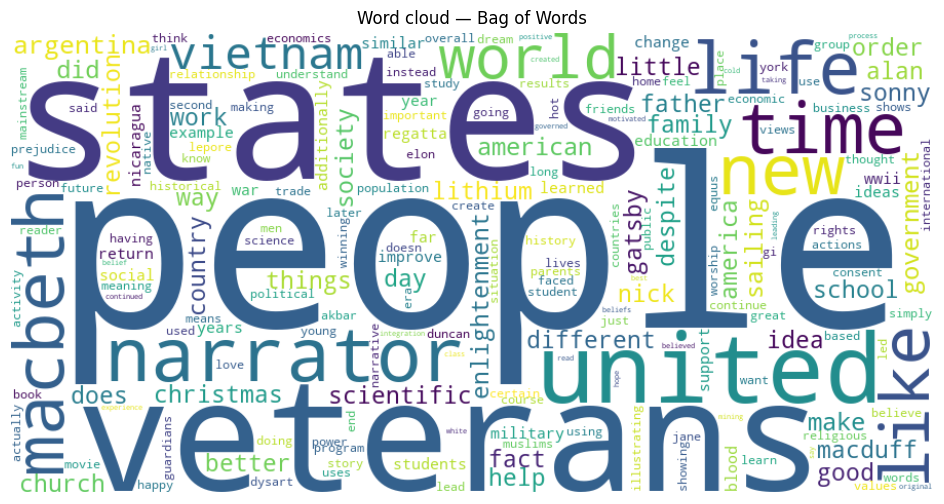

In [13]:
# Word cloud of top BoW words
wc = WordCloud(width=900, height=450, background_color='white',
               colormap='viridis').generate_from_frequencies(word_totals.to_dict())
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word cloud — Bag of Words')
plt.show()

## Apply TF-IDF vectorization to the cleaned text. How is TF-IDF different from simple word counts?

In [14]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)
tfidf_vocab = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vocab)
print(f'TF-IDF matrix shape: {tfidf_df.shape}')
tfidf_df.iloc[:5, :10]

TF-IDF matrix shape: (128, 4173)


,aamerican,abiding,ability,able,abroad,absence,absolute,abstract,absurd,abuse
0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.116837,0.0,0.0,0.0,0.0,0.0,0.0,0.0


TF-IDF decreases the weights of words that appear across many documents and increases the weights of words that are frequent in one document but rare overall. TF-IDF surfaces words that are characteristic of a particular chunk of writing, not just words that I happen to use a lot overall.

## Find the highest TF-IDF words in your dataset. Which words are more unique or meaningful compared to the overall corpus?

In [ ]:
tfidf_avg = tfidf_df.mean(axis=0).sort_values(ascending=False)
tfidf_avg.head(20)

narrator     0.028564
veterans     0.027584
people       0.026620
sailing      0.022838
macbeth      0.022000
argentina    0.021730
states       0.020650
united       0.020367
nick         0.019824
regatta      0.019294
vietnam      0.018864
christmas    0.018801
life         0.018426
world        0.016908
new          0.016892
time         0.016602
sonny        0.016576
like         0.016217
alan         0.016107
elon         0.016100
dtype: float64

of course names of things are pretty much the most meaningful, they mostly only appear in one essay that is about them but very often in those essays so it makes sense. yeah its kind of interesting, I could tell you which essays some of these words are in.

## Compare your Bag of Words results and TF-IDF results. Which words appear frequently, and which words are important but less common?

In [17]:
compare = pd.DataFrame({
    'BoW top 20': word_totals.head(20).index,
    'BoW count': word_totals.head(20).values,
    'TF-IDF top 20': tfidf_avg.head(20).index,
    'TF-IDF score': tfidf_avg.head(20).values.round(4)
})
compare

,BoW top 20,BoW count,TF-IDF top 20,TF-IDF score
0,people,104,narrator,0.0286
1,states,76,veterans,0.0276
2,veterans,71,people,0.0266
3,united,70,sailing,0.0228
4,narrator,64,macbeth,0.0220
5,life,58,argentina,0.0217
6,time,56,states,0.0207
7,new,54,united,0.0204
8,macbeth,53,nick,0.0198
9,like,51,regatta,0.0193


any word that appears in the TF-IDF top 20 but not in Bow top 20 is a word that comes up infrequently in my writing but had some importance maybe 1 or 2 essays I have written. a word that appears in both is probably a little more general, like narrator, which is a word I would use a lot in any essay about a character whose name we dont know. lastly, if the word appears only in Bow, I use it a lot, but the word itself might not have any significance, it is just lucky to not be in the stopword list

## Create at least two visualizations from your TF-IDF analysis.

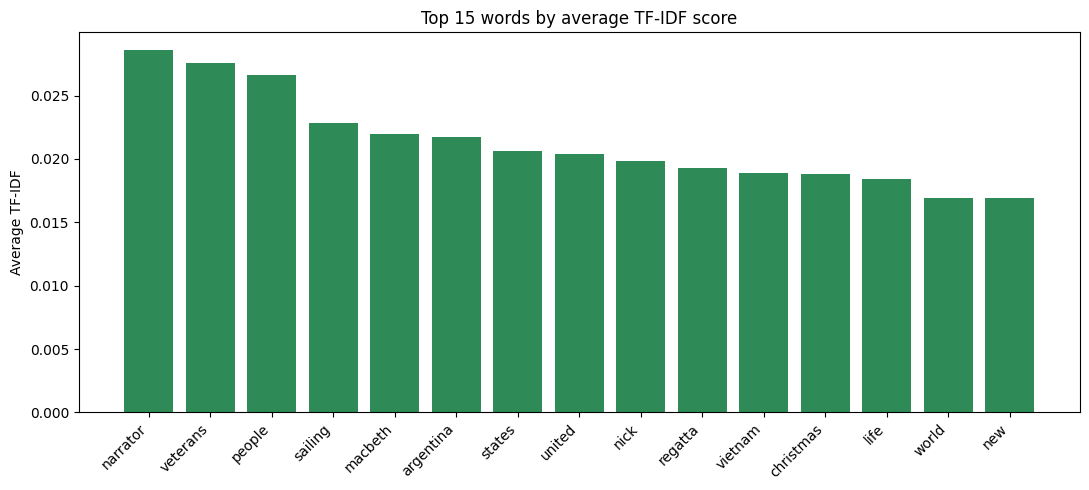

In [ ]:
top15_tfidf = tfidf_avg.head(15)
plt.figure(figsize=(11, 5))
plt.bar(top15_tfidf.index, top15_tfidf.values, color='seagreen')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 words by average TF-IDF score')
plt.ylabel('Average TF-IDF')
plt.tight_layout()
plt.show()

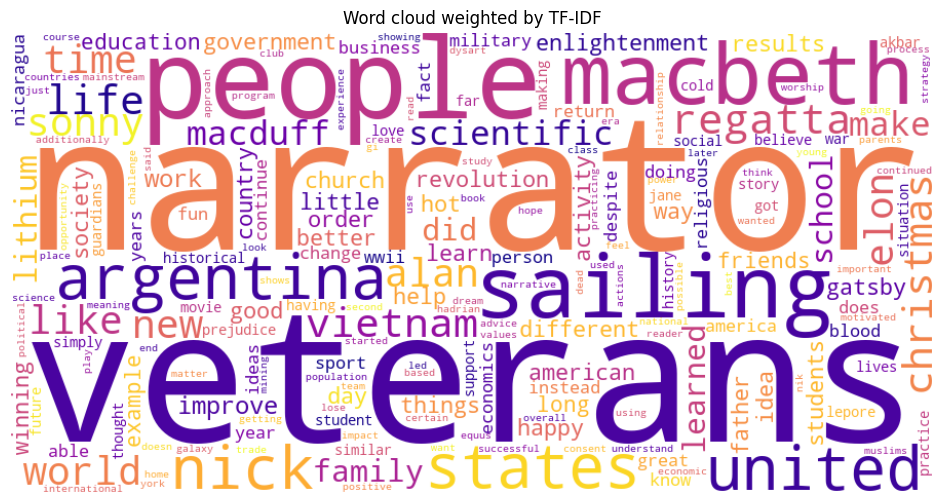

In [ ]:
tfidf_wc = WordCloud(width=900, height=450, background_color='white',
                     colormap='plasma').generate_from_frequencies(tfidf_avg.to_dict())
plt.figure(figsize=(12, 6))
plt.imshow(tfidf_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word cloud weighted by TF-IDF')
plt.show()

## Reflect on your findings. What patterns do you notice about your own academic writing style, vocabulary, themes, or repeated ideas?

I think the content of my writing is all very varied and that is likely because I have essays from as far back as eigth grade included in this, and my writing now is extremely different than it was then. i find it very interesting that 'veterans' has such a high TF-IDF because it is the key word in one research paper I have written but I don't feel like I wrote it so many times. Yeah I don't think there are many repeated ideas in my writing. looking at this word cloud I'm more lost than anything else.